Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las
cámaras digitales modernas. El video a procesar será: “focus_video.mov”.
1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image
Sharpness Measure for Blurred Images in Frequency Domain“ y realizar tres experimentos:
1. Medición sobre todo el frame.
2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.
Opcional:
1. Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores
arbitrarios, probar con varios valores 3x3, 7x5, etc … (al menos 3)
Para cada experimento se debe presentar :
- Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto el punto
de máximo enfoque.
2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure
operators in shapefrom focus.
1. Medicion de foco en toda la imagen
El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera
automática.


In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [26]:
def img_sharpness_measure(img):
  #Dimension del frame
  N = img.shape[0] * img.shape[1]
  #Transformada de Fourier
  F = np.fft.fft2(img)
  #Centrado
  Fc = np.fft.fftshift(F)
  #Valor absoluto de la transformada de Fourier centrada
  AF = np.abs(Fc)
  #Valor máximo
  M = np.max(AF)
  #Contabilizamos los pixeles que superan el threshold
  Th = np.sum(AF > (M/1000))
  return Th/N

In [27]:
# Carga de video
video_path = 'focus_video.mov'
captura_video = cv2.VideoCapture(video_path)
valuesFull = []

while captura_video.isOpened():
  ret, frame = captura_video.read()
  if ret:
  # Procesamiento básico: convertir a escala de grises

    frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    valuesFull.append(img_sharpness_measure(frame_gris))
  else:
    break
# Libera el objeto de captura de video
captura_video.release()
cv2.destroyAllWindows()

#### Roi de 10%
Video es de (360,640) -> 230400 pixeles con una relacion de 360/640 = 0.5625 por lo tanto: el 10% son 23040 pixeles

1)x * y = 23040

2)x/y = 0.5625 deben mantener el mismo ratio

x = 0.5625y
Reemplazamos en la ecuacion 1

0.5625y*y = 23040

y = √(23040/0.5625) = 202

x = 23040/202 = 114

Alto ROI = 114

Ancho ROI = 202

El punto central de imagen original es:
x_centro = 320
y_centro = 180

Por lo tanto a partir del centro generamos el rectangulo que tendra estas coordenadas.

x_izq = 320 - 101 = 219

x_der = 320 + 101 = 421

y_sup = 180 - 57 = 123

y_inf = 180 + 57 = 237


In [28]:
valuesROI = []
x_izq = 219
x_der = 421
y_sup = 123
y_inf = 237
captura_video = cv2.VideoCapture(video_path)
while captura_video.isOpened():
  ret, frame = captura_video.read()
  if ret:
  # Procesamiento básico: convertir a escala de grises
    frame_recortado = frame[y_sup:y_inf,x_izq:x_der]
    frame_gris = cv2.cvtColor(frame_recortado, cv2.COLOR_BGR2GRAY)
    valuesROI.append(img_sharpness_measure(frame_gris))
  else:
    break
# Libera el objeto de captura de video
captura_video.release()
cv2.destroyAllWindows()

# Graficado

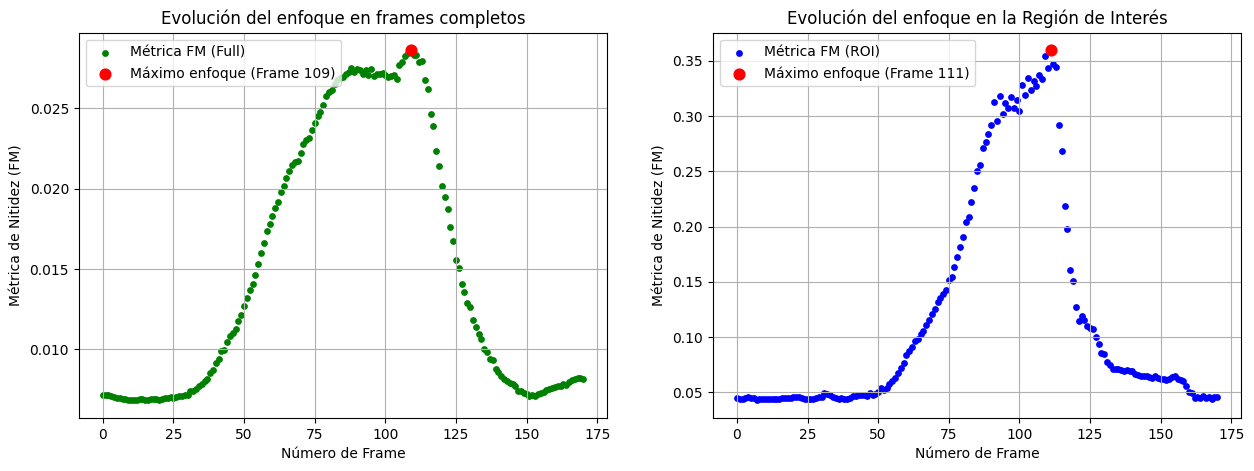

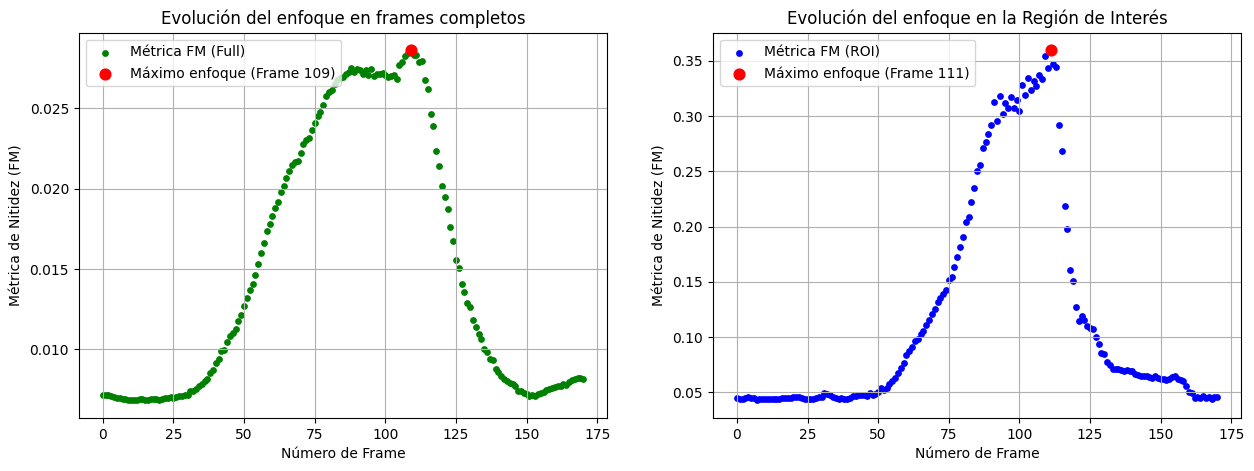

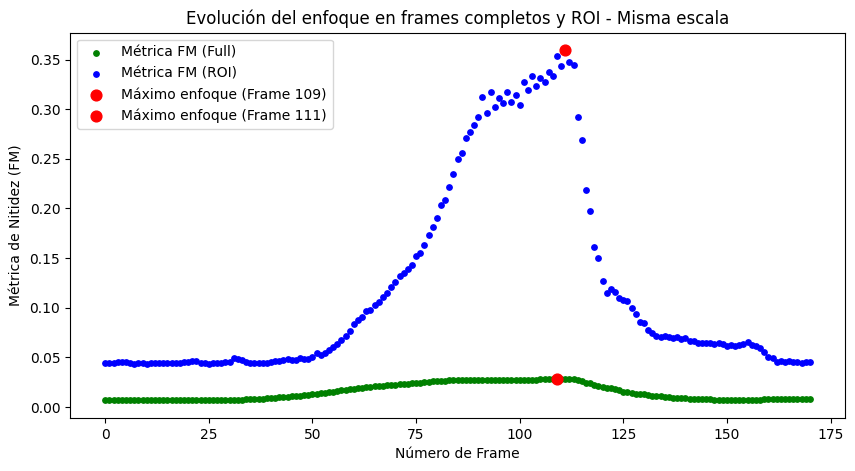

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Buscamos el punto máximo
max_frame_full = np.argmax(valuesFull)
max_value_full = valuesFull[max_frame_full]
max_frame_roi = np.argmax(valuesROI)
max_value_roi = valuesROI[max_frame_roi]

# Preparamos el eje X (lista de números del 0 hasta el total de frames)
eje_x = range(len(valuesROI))

fig,(ax1,ax2) = plt.subplots(1,2, figsize=(15, 5))

# Creamos el gráfico de puntos. 's' controla el tamaño del punto.
ax1.scatter(eje_x, valuesFull, color='green', label='Métrica FM (Full)', s=15)
ax2.scatter(eje_x, valuesROI, color='blue', label='Métrica FM (ROI)', s=15)

# Resaltamos el punto de máximo enfoque con un punto rojo más grande
ax1.scatter(max_frame_full, max_value_full, color='red', label=f'Máximo enfoque (Frame {max_frame_full})', s=60)
ax2.scatter(max_frame_roi, max_value_roi, color='red', label=f'Máximo enfoque (Frame {max_frame_roi})', s=60)



ax1.set_title('Evolución del enfoque en frames completos')
ax1.set_xlabel('Número de Frame')
ax1.set_ylabel('Métrica de Nitidez (FM)')
ax2.set_title('Evolución del enfoque en la Región de Interés')
ax2.set_xlabel('Número de Frame')
ax2.set_ylabel('Métrica de Nitidez (FM)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')
ax1.grid(True)
ax2.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(eje_x, valuesFull, color='green', label='Métrica FM (Full)', s=15)
ax.scatter(eje_x, valuesROI, color='blue', label='Métrica FM (ROI)', s=15)
ax.scatter(max_frame_full, max_value_full, color='red', label=f'Máximo enfoque (Frame {max_frame_full})', s=60)
ax.scatter(max_frame_roi, max_value_roi, color='red', label=f'Máximo enfoque (Frame {max_frame_roi})', s=60)
ax.set_title('Evolución del enfoque en frames completos y ROI - Misma escala')
ax.set_xlabel('Número de Frame')
ax.set_ylabel('Métrica de Nitidez (FM)')
ax.legend(loc='upper left')
plt.show()

### Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure operators in shapefrom focus.
Varianza del Laplaciano

In [20]:
valuesLP = []

captura_video = cv2.VideoCapture(video_path)
while captura_video.isOpened():
  ret, frame = captura_video.read()
  if ret:
    frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    laplacian = cv2.Laplacian(frame_gris, cv2.CV_64F)
    valuesLP.append(np.var(laplacian))
  else:
    break
# Libera el objeto de captura de video
captura_video.release()
cv2.destroyAllWindows()


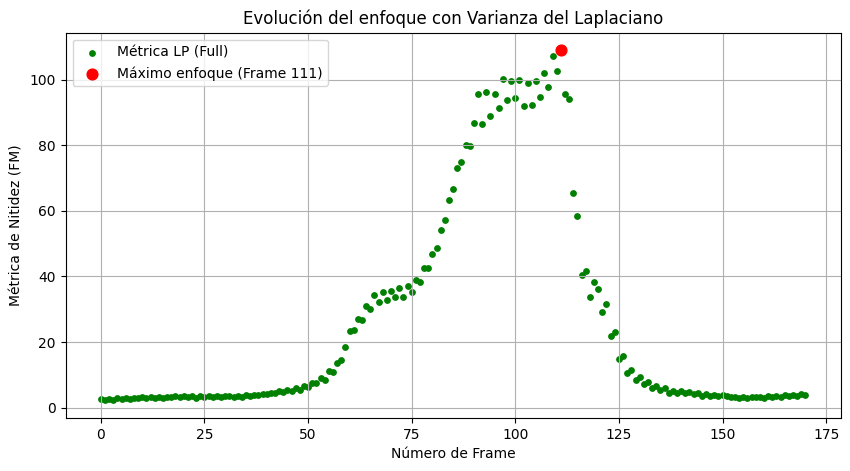

In [21]:
# Buscamos el punto máximo
max_frame_LP = np.argmax(valuesLP)
max_value_LP = valuesLP[max_frame_LP]


# Preparamos el eje X (lista de números del 0 hasta el total de frames)
eje_x = range(len(valuesLP))

plt.figure(figsize=(10,5))

# Creamos el gráfico de puntos. 's' controla el tamaño del punto.
plt.scatter(eje_x, valuesLP, color='green', label='Métrica LP (Full)', s=15)


# Resaltamos el punto de máximo enfoque con un punto rojo más grande
plt.scatter(max_frame_LP, max_value_LP, color='red', label=f'Máximo enfoque (Frame {max_frame_LP})', s=60)


plt.title('Evolución del enfoque con Varianza del Laplaciano')
plt.xlabel('Número de Frame')
plt.ylabel('Métrica de Nitidez (FM)')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

## Opcional: matriz de enfoque

La idea de esta parte es no mirar el frame como una sola cosa, sino partirlo en una grilla. Para cada celda calculamos la misma metrica espectral y despues resumimos el frame con dos valores:

- promedio de foco de todas las celdas
- mejor celda del frame

Sirve para ver si el foco aparece parejo en toda la imagen o si hay zonas que dominan la medicion.

In [22]:
from pathlib import Path


# --------------

def metricasGridFrame(frameGris, filas, cols):
    alto, ancho = frameGris.shape
    mapaFoco = np.zeros((filas, cols))

    for filaIdx in range(filas):
        for colIdx in range(cols):
            yIni = int(filaIdx * alto / filas)
            yFin = int((filaIdx + 1) * alto / filas)
            xIni = int(colIdx * ancho / cols)
            xFin = int((colIdx + 1) * ancho / cols)

            celda = frameGris[yIni:yFin, xIni:xFin]
            mapaFoco[filaIdx, colIdx] = img_sharpness_measure(celda)

    return mapaFoco


def calcularFocoGridVideo(videoPath, filas, cols):
    cap = cv2.VideoCapture(str(videoPath))
    serieProm = []
    serieMax = []
    mapasPorFrame = []
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frameGris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        mapaFoco = metricasGridFrame(frameGris, filas, cols)
        mapasPorFrame.append(mapaFoco)
        serieProm.append(mapaFoco.mean())
        serieMax.append(mapaFoco.max())

    cap.release()
    return np.array(serieProm), np.array(serieMax), mapasPorFrame

# --------------

grillasTest = [(3, 3), (5, 5), (7, 5)]
resultadosGrid = {}
videoPath = Path('focus_video.mov')

for filas, cols in grillasTest:
    serieProm, serieMax, mapasPorFrame = calcularFocoGridVideo(videoPath, filas, cols)
    nombreGrid = f'{filas}x{cols}'

    if len(serieProm) == 0:
        continue

    frameMaxProm = int(np.argmax(serieProm))
    frameMaxCelda = int(np.argmax(serieMax))

    resultadosGrid[nombreGrid] = {
        'serieProm': serieProm,
        'serieMax': serieMax,
        'mapasPorFrame': mapasPorFrame,
        'frameMaxProm': frameMaxProm,
        'frameMaxCelda': frameMaxCelda,
    }

    print(f'{nombreGrid}: max promedio frame {frameMaxProm} | max celda frame {frameMaxCelda}')

3x3: max promedio frame 105 | max celda frame 105
5x5: max promedio frame 111 | max celda frame 109
7x5: max promedio frame 111 | max celda frame 87


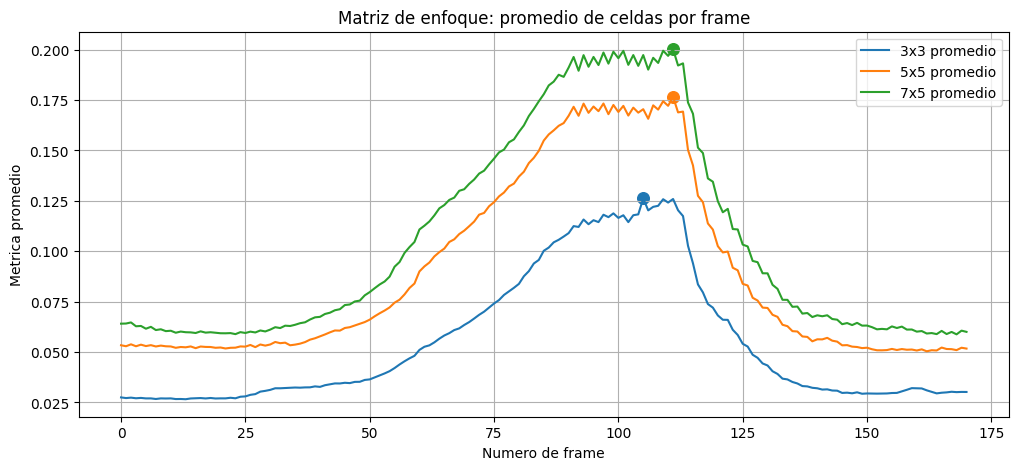

In [24]:
plt.figure(figsize=(12, 5))

for nombreGrid, datosGrid in resultadosGrid.items():
    serieProm = datosGrid['serieProm']
    frameMax = datosGrid['frameMaxProm']
    plt.plot(serieProm, label=f'{nombreGrid} promedio')
    plt.scatter(frameMax, serieProm[frameMax], s=70)

plt.title('Matriz de enfoque: promedio de celdas por frame')
plt.xlabel('Numero de frame')
plt.ylabel('Metrica promedio')
plt.grid(True)
plt.legend()
plt.show()

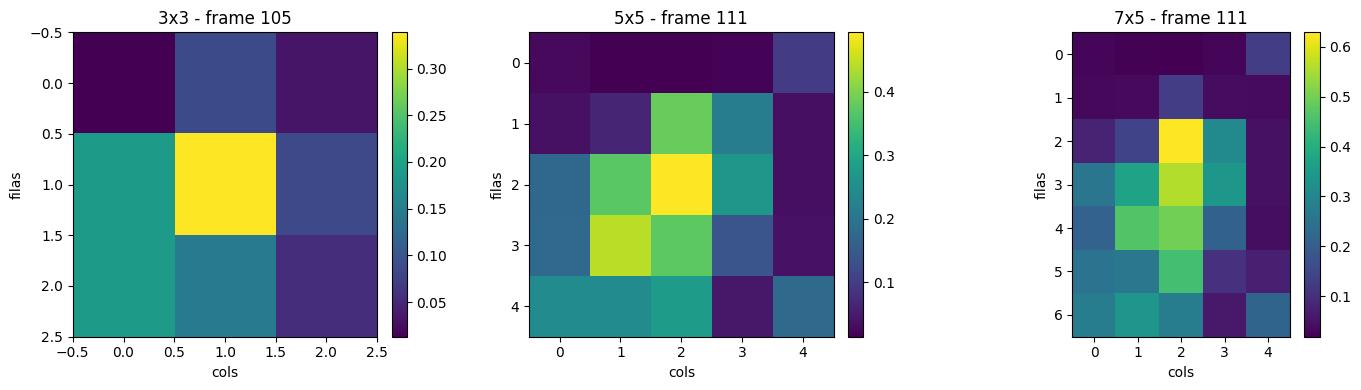

In [ ]:
fig, axs = plt.subplots(1, len(resultadosGrid), figsize=(14, 4))

if len(resultadosGrid) == 1:
    axs = [axs]

for ax, (nombreGrid, datosGrid) in zip(axs, resultadosGrid.items()):
    frameMax = datosGrid['frameMaxProm']
    mapaMax = datosGrid['mapasPorFrame'][frameMax]
    im = ax.imshow(mapaMax, cmap='viridis')
    ax.set_title(f'{nombreGrid} - frame {frameMax}')
    ax.set_xlabel('cols')
    ax.set_ylabel('filas')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()